In [1]:
#importing the Libraies
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Reading the Dataset
dataset = pd.read_csv('Social_Network_Ads.csv')

In [3]:
dataset

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
dataset

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [5]:
dataset=pd.get_dummies(dataset,drop_first=True)

In [6]:
dataset

,User ID,Age,EstimatedSalary,Purchased,Gender_Male
0,15624510,19,19000,0,True
1,15810944,35,20000,0,True
2,15668575,26,43000,0,False
3,15603246,27,57000,0,False
4,15804002,19,76000,0,True
...,...,...,...,...,...
395,15691863,46,41000,1,False
396,15706071,51,23000,1,True
397,15654296,50,20000,1,False
398,15755018,36,33000,0,True


In [7]:
indep=dataset[['Age', 'EstimatedSalary','Gender_Male']]
dep=dataset['Purchased']

In [8]:
#split into training set and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(indep, dep, test_size = 1/3, random_state = 0)


In [9]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {'solver':['newton-cg', 'lbfgs', 'liblinear', 'saga'],
             'penalty':['l2']} 

grid = GridSearchCV(LogisticRegression(), param_grid, refit = True, verbose = 3,n_jobs=-1,scoring='f1_weighted') 
   
# fitting the model for grid search 
grid.fit(X_train, y_train) 
 



Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'penalty': ['l2'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'saga']},
             scoring='f1_weighted', verbose=3)

In [26]:
print(grid.best_params_)

{'penalty': 'l2', 'solver': 'liblinear'}


In [13]:
# print best parameter after tuning 
#print(grid.best_params_) 
re=grid.cv_results_
#print(re)
grid_predictions = grid.predict(X_test) 

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, grid_predictions)

# print classification report 
from sklearn.metrics import classification_report
clf_report = classification_report(y_test, grid_predictions)




In [15]:
print(grid.best_params_)

{'penalty': 'l2', 'solver': 'liblinear'}


In [24]:
re

{'mean_fit_time': array([0.02903538, 0.00933599, 0.00407081, 0.0043169 ]),
 'std_fit_time': array([0.01475119, 0.00630444, 0.0013144 , 0.00106976]),
 'mean_score_time': array([0.00533495, 0.00576258, 0.00410066, 0.00514154]),
 'std_score_time': array([2.61135101e-03, 5.31588920e-03, 9.99051344e-05, 2.29150793e-03]),
 'param_penalty': masked_array(data=['l2', 'l2', 'l2', 'l2'],
              mask=[False, False, False, False],
        fill_value='?',
             dtype=object),
 'param_solver': masked_array(data=['newton-cg', 'lbfgs', 'liblinear', 'saga'],
              mask=[False, False, False, False],
        fill_value='?',
             dtype=object),
 'params': [{'penalty': 'l2', 'solver': 'newton-cg'},
  {'penalty': 'l2', 'solver': 'lbfgs'},
  {'penalty': 'l2', 'solver': 'liblinear'},
  {'penalty': 'l2', 'solver': 'saga'}],
 'split0_test_score': array([0.79962013, 0.79962013, 0.80476365, 0.79962013]),
 'split1_test_score': array([0.81132075, 0.81132075, 0.81132075, 0.81132075]),
 '

In [16]:
print("The confusion Matrix:\n",cm)

The confusion Matrix:
 [[79  6]
 [10 39]]


In [17]:
print("The report:\n",clf_report)

The report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91        85
           1       0.87      0.80      0.83        49

    accuracy                           0.88       134
   macro avg       0.88      0.86      0.87       134
weighted avg       0.88      0.88      0.88       134



In [18]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test,grid.predict_proba(X_test)[:,1])


0.9507803121248499

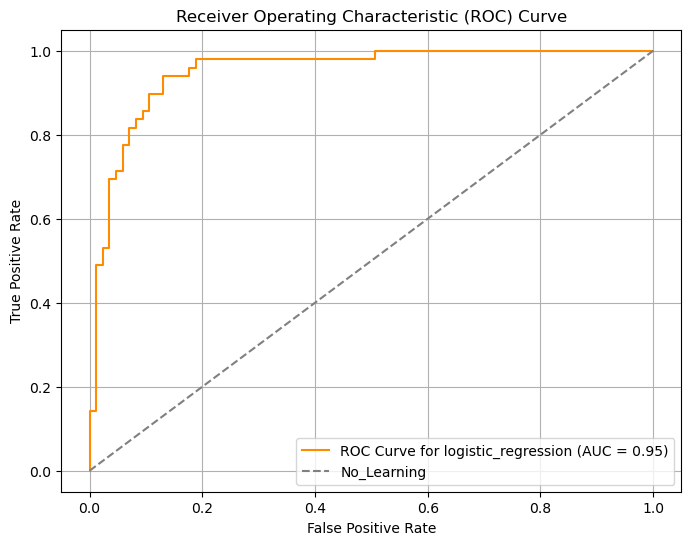

In [19]:
from sklearn.metrics import roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_probs = grid.predict_proba(X_test)[:, 1]

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Plot the ROC curve
plt.figure(figsize=(8, 6))

# Plot ROC curve
plt.plot(fpr, tpr, label=f'ROC Curve for logistic_regression (AUC = {roc_auc_score(y_test, y_probs):.2f})', color='darkorange')

# Plot diagonal line with label
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='No_Learning')

# Add labels and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [20]:
table=pd.DataFrame.from_dict(re)

In [21]:
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_penalty,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.029035,0.014751,0.005335,0.002611,l2,newton-cg,"{'penalty': 'l2', 'solver': 'newton-cg'}",0.799620,0.811321,0.68205,0.92351,0.922185,0.827737,0.089864,2
1,0.009336,0.006304,0.005763,0.005316,l2,lbfgs,"{'penalty': 'l2', 'solver': 'lbfgs'}",0.799620,0.811321,0.68205,0.92351,0.922185,0.827737,0.089864,2
2,0.004071,0.001314,0.004101,0.000100,l2,liblinear,"{'penalty': 'l2', 'solver': 'liblinear'}",0.804764,0.811321,0.68205,0.92351,0.922185,0.828766,0.089565,1
3,0.004317,0.001070,0.005142,0.002292,l2,saga,"{'penalty': 'l2', 'solver': 'saga'}",0.799620,0.811321,0.68205,0.92351,0.922185,0.827737,0.089864,2


In [22]:
Social_network_Ads_Prediction=grid.predict([[25,25000,0]])
print("Social_network_Ads_Prediction={}".format(Social_network_Ads_Prediction))

Social_network_Ads_Prediction=[1]
